# Feature Scaling - Companion Notebook

This notebook contains only code and short operational notes that complement [`lecture_notes/11_feature_scaling.pdf`](../../lecture_notes/11_feature_scaling.pdf). The theory, formulas, and method-selection criteria are covered in the lecture notes.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, OneHotEncoder, RobustScaler, StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42


This setup cell imports the libraries used throughout the notebook and fixes a random seed for reproducibility. It also defines the plotting style so that the figures have a consistent appearance across all experiments.

In [56]:
def plot_histograms(frame, columns, title, bins=30, figsize=(16, 3), apply_zoom = False):
    fig, axes = plt.subplots(1, len(columns), figsize=figsize, sharey=False)
    if len(columns) == 1:
        axes = [axes]

    for ax, column in zip(axes, columns):
        ax.hist(frame[column], bins=bins, edgecolor="black", alpha=0.75, color="tab:blue")
        ax.set_title(column)
        ax.set_xlabel("value")
        if apply_zoom and column != "original":
            ax.set_xlim(-3, 3)

    fig.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()


def make_scaler_comparison(series):
    data = pd.DataFrame({"original": series})
    data["minmax"] = MinMaxScaler().fit_transform(data[["original"]])
    data["standard"] = StandardScaler().fit_transform(data[["original"]])
    data["robust"] = RobustScaler().fit_transform(data[["original"]])
    data["log1p"] = np.log1p(data["original"])
    return data


This cell defines two helper functions used repeatedly in the notebook.

- `plot_histograms(...)` displays side-by-side histograms so that the effect of each transformation can be compared visually.
- `make_scaler_comparison(...)` builds a single DataFrame containing the original feature together with its transformed versions under Min-Max scaling, Standard scaling, Robust scaling, and `log1p`.

Keeping these operations in helper functions makes the later cells shorter and easier to read.

## Compare Scaling Methods on a Right-Skewed Feature

A practical comparison of Min-Max, Standard, Robust, and `log1p` on a positively skewed variable with a long right tail.

In [57]:
rng = np.random.default_rng(SEED)
income = pd.Series(rng.lognormal(mean=10.2, sigma=0.9, size=1500), name="income")
scaled_income = make_scaler_comparison(income)

scaled_income.describe().round(3)


,original,minmax,standard,robust,log1p
count,1500.000,1500.000,1500.000,1500.000,1500.000
mean,39337.668,0.082,0.000,0.381,10.182
std,42004.971,0.090,1.000,1.295,0.900
min,1008.711,0.000,-0.913,-0.801,6.917
25%,14602.717,0.029,-0.589,-0.382,9.589
50%,26986.910,0.055,-0.294,0.000,10.203
75%,47049.015,0.098,0.184,0.618,10.759
max,470225.813,1.000,10.261,13.661,13.061


This cell generates a synthetic income-like variable using a log-normal distribution, which naturally produces a strong right skew. It then applies all transformations through `make_scaler_comparison(...)` and prints summary statistics for each version.

The goal is not to choose a model yet, but to create a controlled example in which the effect of each transformation can be inspected numerically before looking at the plots.

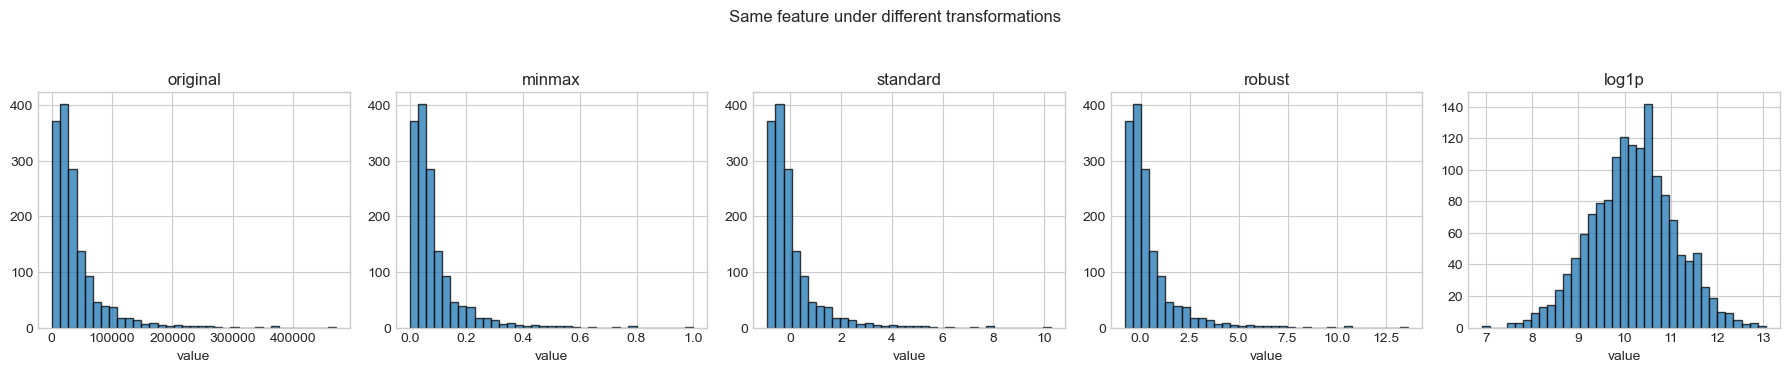

In [58]:
plot_histograms(
    scaled_income,
    ["original", "minmax", "standard", "robust", "log1p"],
    title="Same feature under different transformations",
    bins=35,
    figsize=(18, 3.5),
)


This plot is the visual counterpart of the summary table above. Because all transformed versions come from the same original feature, differences across histograms can be attributed to the transformation itself.

When reading the figure, focus on how each method changes:
- the asymmetry of the distribution,
- the spread of the bulk of the data, and
- the visibility of the long right tail.

This is especially useful for seeing why `log1p` is often discussed alongside scaling methods when the feature is strongly right-skewed.

## Effect of one extreme outlier

In this experiment, we start with an approximately normal feature and inject **a single extreme outlier (value = 500)**. We then apply different scaling methods and observe **how the resulting distributions change**.

---

## What to look for in the histograms

### **Original**
- Most values are concentrated in a narrow range (~30-70)
- The outlier appears isolated on the right  
This serves as a visual baseline for comparison.

### **MinMax**
- Almost all values are compressed near 0
- The outlier sets the maximum (mapped to 1)  
Visible effect: loss of resolution among the main data points.

### **Standard**
- The distribution is centered, but highly concentrated around 0
- The outlier still appears far away  
Visible effect: compression caused by an inflated global scale.

### **Robust**
- The main bulk of the data remains well spread
- The outlier is still far away, but does not distort the rest  
Visible effect: better preservation of the central structure of the data.

---

## Comparative reading

- **MinMax and Standard** are strongly affected by the outlier, so most of the data gets compressed.
- **Robust** is much less affected, so it preserves the structure of the majority of the observations.

---

## Main takeaway

A single extreme outlier can drastically change how data is represented after scaling.

When inspecting the plots, ask: **Can I still distinguish variation among the main data points?**  
If the answer is no, then that scaler is probably a poor choice for this scenario.

---

## Suggested exploration

Try removing the outlier and compare the new plots with the current ones. The contrast usually makes the role of the outlier even clearer.

In [59]:
base = rng.normal(loc=50, scale=8, size=200)
feature_with_outlier = pd.Series(np.append(base, 500), name="feature")
scaled_outlier = make_scaler_comparison(feature_with_outlier)

summary = pd.DataFrame({
    "min": scaled_outlier.min(),
    "median": scaled_outlier.median(),
    "max": scaled_outlier.max(),
}).round(3)
summary


,min,median,max
original,28.003,49.160,500.000
minmax,0.000,0.045,1.000
standard,-0.703,-0.058,13.694
robust,-2.096,0.000,44.666
log1p,3.367,3.915,6.217


This cell constructs a mostly well-behaved feature and then appends a single extreme value. After applying the transformations, it summarizes the minimum, median, and maximum of each transformed version.

The table is useful because it gives a compact numerical view of what the outlier is doing to each transformation. In particular, it helps connect the later histograms to concrete changes in scale and range.

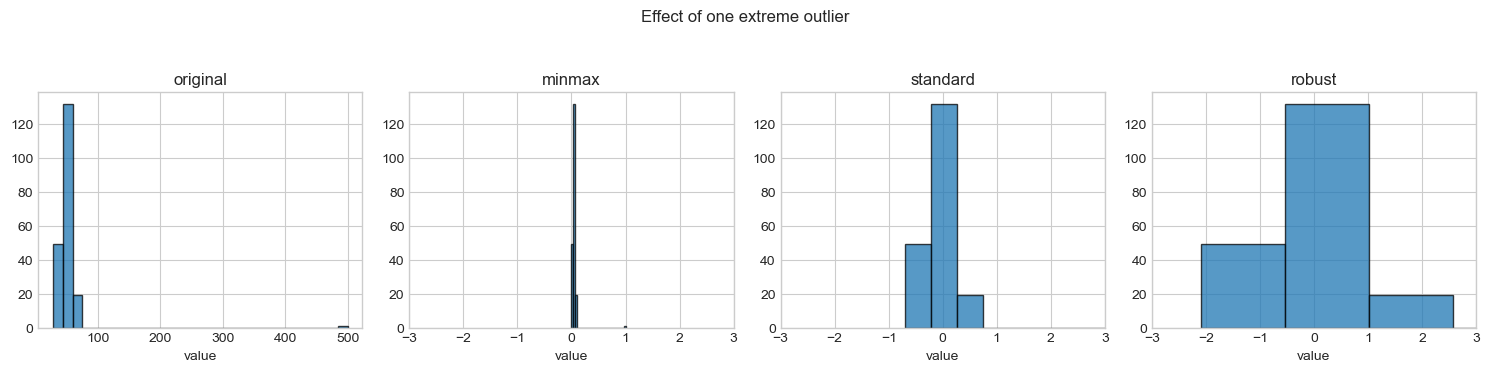

In [60]:
plot_histograms(
    scaled_outlier,
    ["original", "minmax", "standard", "robust"],
    title="Effect of one extreme outlier",
    bins=30,
    figsize=(15, 3.5),
    apply_zoom=True
)


This figure provides the visual inspection for the outlier experiment. The main question here is whether the transformation preserves meaningful variation among the non-outlier observations.

A good way to read the plots is to compare the dense central region across methods. If most regular observations collapse into a very narrow band, then the scaler is reacting too strongly to the extreme value.

## Min-Max on Unseen Test Ranges

This section shows that test values may fall below 0 or above 1 when they lie outside the range observed during training.

In [61]:
X_train_demo = np.array([[10.0], [20.0], [30.0], [40.0]])
X_test_demo = np.array([[5.0], [25.0], [60.0]])

mm = MinMaxScaler()
X_train_demo_scaled = mm.fit_transform(X_train_demo)
X_test_demo_scaled = mm.transform(X_test_demo)

pd.DataFrame({
    "raw_test": X_test_demo.ravel(),
    "scaled_test": X_test_demo_scaled.ravel(),
})


,raw_test,scaled_test
0,5.0,-0.166667
1,25.0,0.500000
2,60.0,1.666667


This example shows a subtle but important point about Min-Max scaling: the interval `[0, 1]` is guaranteed only for the data used in `fit`, not for future data in general.

Because the scaler is fitted on training values between 10 and 40, a test value below 10 is mapped to a negative number, and a test value above 40 is mapped to a number greater than 1. This is a useful reminder that transformed test values can fall outside the nominal Min-Max range whenever the test distribution extends beyond the training range.

## Why Scaling Matters for Distance-Based Models

A practical companion to the motivation in the lecture notes: compare k-NN performance with and without scaling.

In [62]:
X_bc, y_bc = load_breast_cancer(return_X_y=True)
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.25, stratify=y_bc, random_state=SEED
)

knn_raw = KNeighborsClassifier(n_neighbors=7)
knn_raw.fit(X_train_bc, y_train_bc)
pred_raw = knn_raw.predict(X_test_bc)

knn_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=7)),
])
knn_scaled.fit(X_train_bc, y_train_bc)
pred_scaled = knn_scaled.predict(X_test_bc)

pd.DataFrame([
    {"setup": "k-NN without scaling", "test_accuracy": accuracy_score(y_test_bc, pred_raw)},
    {"setup": "k-NN with StandardScaler", "test_accuracy": accuracy_score(y_test_bc, pred_scaled)},
]).round(4)


,setup,test_accuracy
0,k-NN without scaling,0.9441
1,k-NN with StandardScaler,0.9790


This cell compares k-NN on the breast cancer dataset with and without standardization. The two models are identical except for the presence of `StandardScaler()` in the pipeline.

Since k-NN relies directly on distances, this is a concrete demonstration of why feature scaling is not just cosmetic. If some variables dominate the distance computation because of their scale, predictive performance may degrade noticeably.

## Treat the Scaler as Part of the Pipeline

Here the scaler itself is selected by cross-validation, instead of being chosen outside the pipeline.

In [63]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X_bc, y_bc, test_size=0.20, stratify=y_bc, random_state=SEED
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000)),
])

search = GridSearchCV(
    pipeline,
    param_grid={
        "scaler": [StandardScaler(), RobustScaler(), MinMaxScaler()],
        "model__C": [0.1, 1.0, 10.0],
    },
    cv=5,
    scoring="accuracy",
)
search.fit(X_dev, y_dev)

results = pd.DataFrame(search.cv_results_)[[
    "param_scaler",
    "param_model__C",
    "mean_test_score",
    "rank_test_score",
]].sort_values(["rank_test_score", "mean_test_score"])

results.head(9)


,param_scaler,param_model__C,mean_test_score,rank_test_score
0,StandardScaler(),0.1,0.980220,1
3,StandardScaler(),1.0,0.980220,1
4,RobustScaler(),1.0,0.980220,1
8,MinMaxScaler(),10.0,0.980220,1
1,RobustScaler(),0.1,0.975824,5
5,MinMaxScaler(),1.0,0.971429,6
7,RobustScaler(),10.0,0.971429,6
6,StandardScaler(),10.0,0.969231,8
2,MinMaxScaler(),0.1,0.929670,9


This cell treats the scaler as a tunable preprocessing choice inside the pipeline. `GridSearchCV` evaluates different scalers together with different values of the logistic regression regularization parameter `C`.

The key idea is methodological: preprocessing decisions should be validated in the same cross-validation procedure as the model itself. This avoids selecting a scaler by informal inspection alone and reinforces the principle that preprocessing is part of the modeling pipeline.

In [64]:
best_model = search.best_estimator_
test_score = best_model.score(X_test, y_test)

print("Best configuration:", search.best_params_)
print(f"Cross-validation accuracy: {search.best_score_:.4f}")
print(f"Held-out test accuracy:    {test_score:.4f}")


Best configuration: {'model__C': 0.1, 'scaler': StandardScaler()}
Cross-validation accuracy: 0.9802
Held-out test accuracy:    0.9737


This cell moves from validation to final evaluation. After cross-validation identifies the best pipeline configuration, that fitted pipeline is evaluated on the held-out test set.

Read the three printed lines together:
- the best hyperparameter configuration found during cross-validation,
- its mean cross-validation score, and
- the final performance on unseen test data.

The comparison between cross-validation accuracy and held-out test accuracy also gives a quick sense of whether the selected pipeline generalizes as expected.

## Mixed-Type Preprocessing with ColumnTransformer

A minimal example showing how to scale only numerical columns while encoding categorical columns in the same pipeline.

In [65]:
toy_df = pd.DataFrame({
    "age": [23, 45, 31, 52, 46, 28],
    "income": [2200, 7800, 3200, 9200, 8500, 2800],
    "city": ["RJ", "SP", "RJ", "BH", "SP", "BH"],
    "segment": ["A", "B", "A", "B", "B", "A"],
})

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), ["age", "income"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["city", "segment"]),
])

Xt = preprocessor.fit_transform(toy_df)
feature_names = preprocessor.get_feature_names_out()
pd.DataFrame(Xt, columns=feature_names).round(3)


,num__age,num__income,cat__city_BH,cat__city_RJ,cat__city_SP,cat__segment_A,cat__segment_B
0,-1.361,-1.168,0.0,1.0,0.0,1.0,0.0
1,0.704,0.746,0.0,0.0,1.0,0.0,1.0
2,-0.610,-0.826,0.0,1.0,0.0,1.0,0.0
3,1.361,1.225,1.0,0.0,0.0,0.0,1.0
4,0.798,0.985,0.0,0.0,1.0,0.0,1.0
5,-0.891,-0.963,1.0,0.0,0.0,1.0,0.0


This example shows how preprocessing is usually organized when a dataset mixes numerical and categorical variables. Numerical columns are imputed and scaled, while categorical columns are one-hot encoded.

The resulting transformed table is useful to inspect because it makes the output of `ColumnTransformer` concrete: each original variable is turned into a set of model-ready features, and only the numerical subset is standardized.